In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
# Kaggle API setup
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Dataset download
!kaggle datasets download -d prevek18/ames-housing-dataset

# Unzip dataset
!unzip ames-housing-dataset.zip

# Load dataset


df = pd.read_csv("AmesHousing.csv")


Dataset URL: https://www.kaggle.com/datasets/prevek18/ames-housing-dataset
License(s): unknown
100% 185k/185k [00:00<00:00, 38.1MB/s]

Archive:  ames-housing-dataset.zip
  inflating: AmesHousing.csv         


In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)


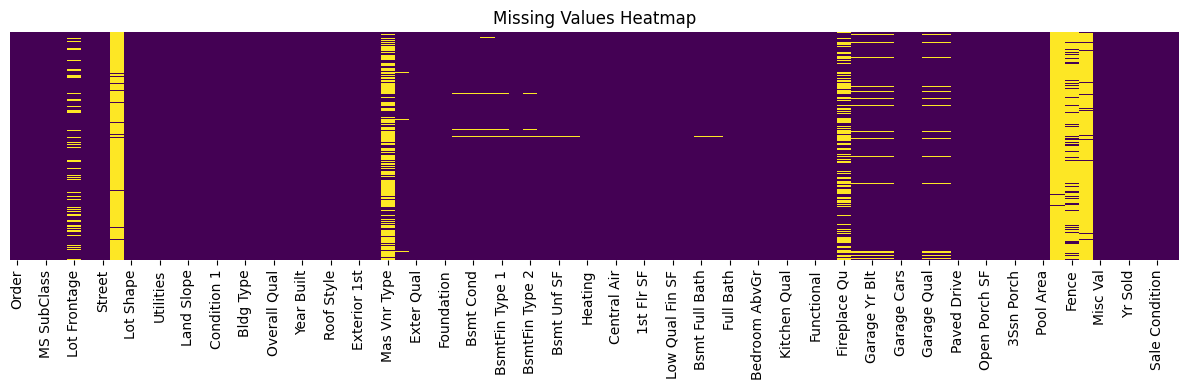

In [4]:

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

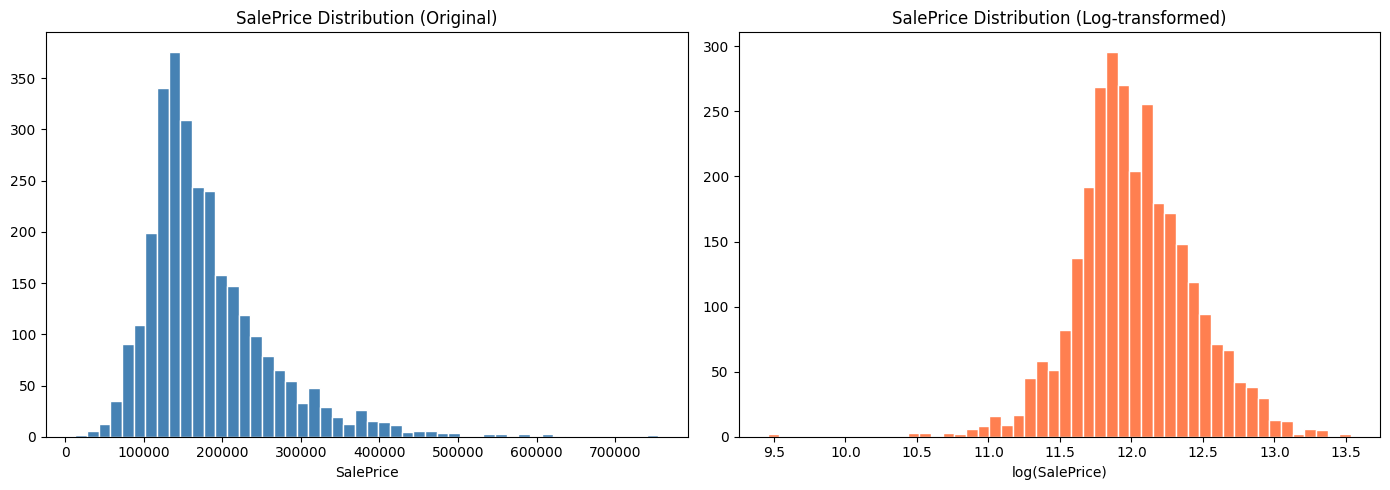

Skewness (original): 1.744
Skewness (log):      -0.015


In [5]:
# ── 2.3 Target Distribution ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Original)')
axes[0].set_xlabel('SalePrice')

# Log-transformed
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log-transformed)')
axes[1].set_xlabel('log(SalePrice)')

plt.tight_layout()
plt.show()

print(f"Skewness (original): {df['SalePrice'].skew():.3f}")
print(f"Skewness (log):      {np.log1p(df['SalePrice']).skew():.3f}")

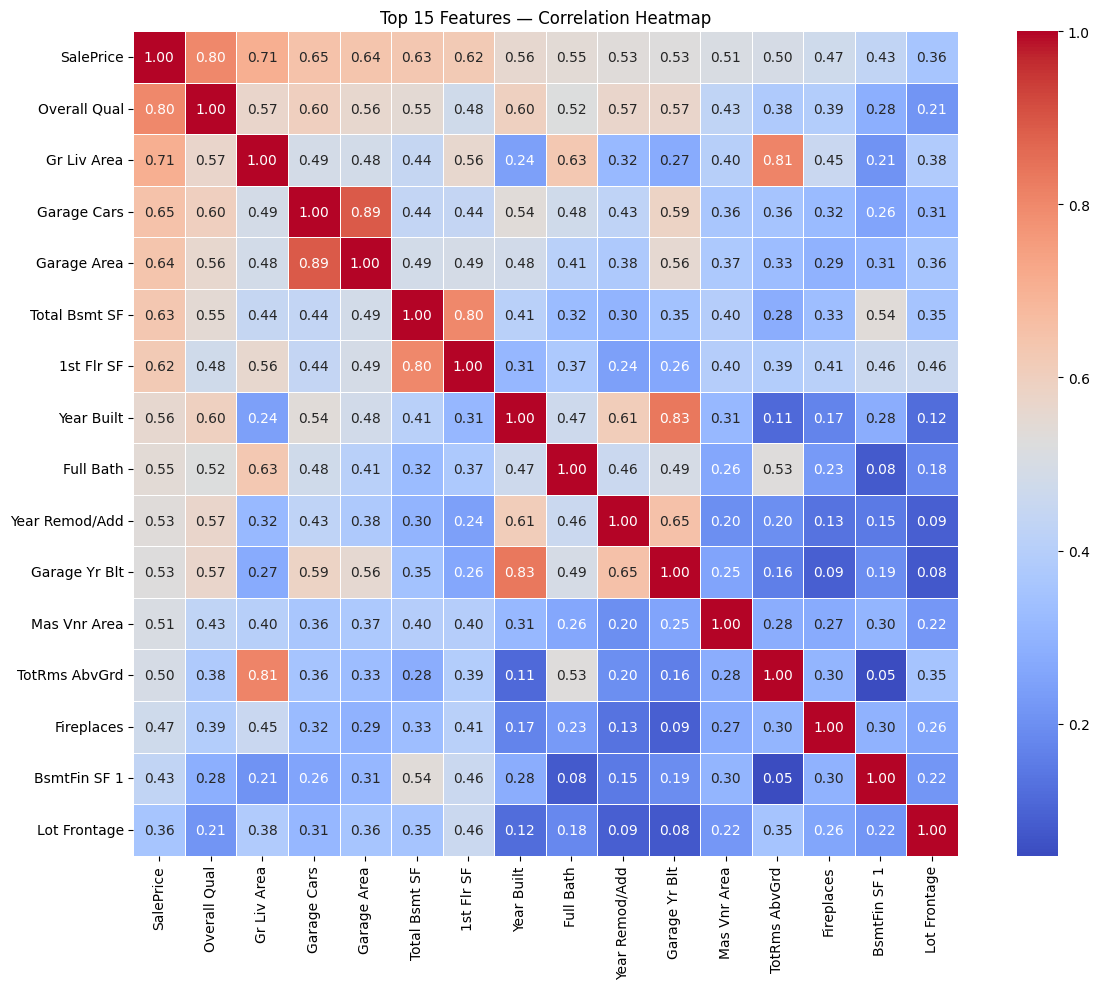

In [6]:
# ── 2.4 Correlation Heatmap (Numerical) ─────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

# Top 15 correlated with SalePrice
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(13, 10))
sns.heatmap(df[top_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Top 15 Features — Correlation Heatmap')
plt.tight_layout()
plt.show()

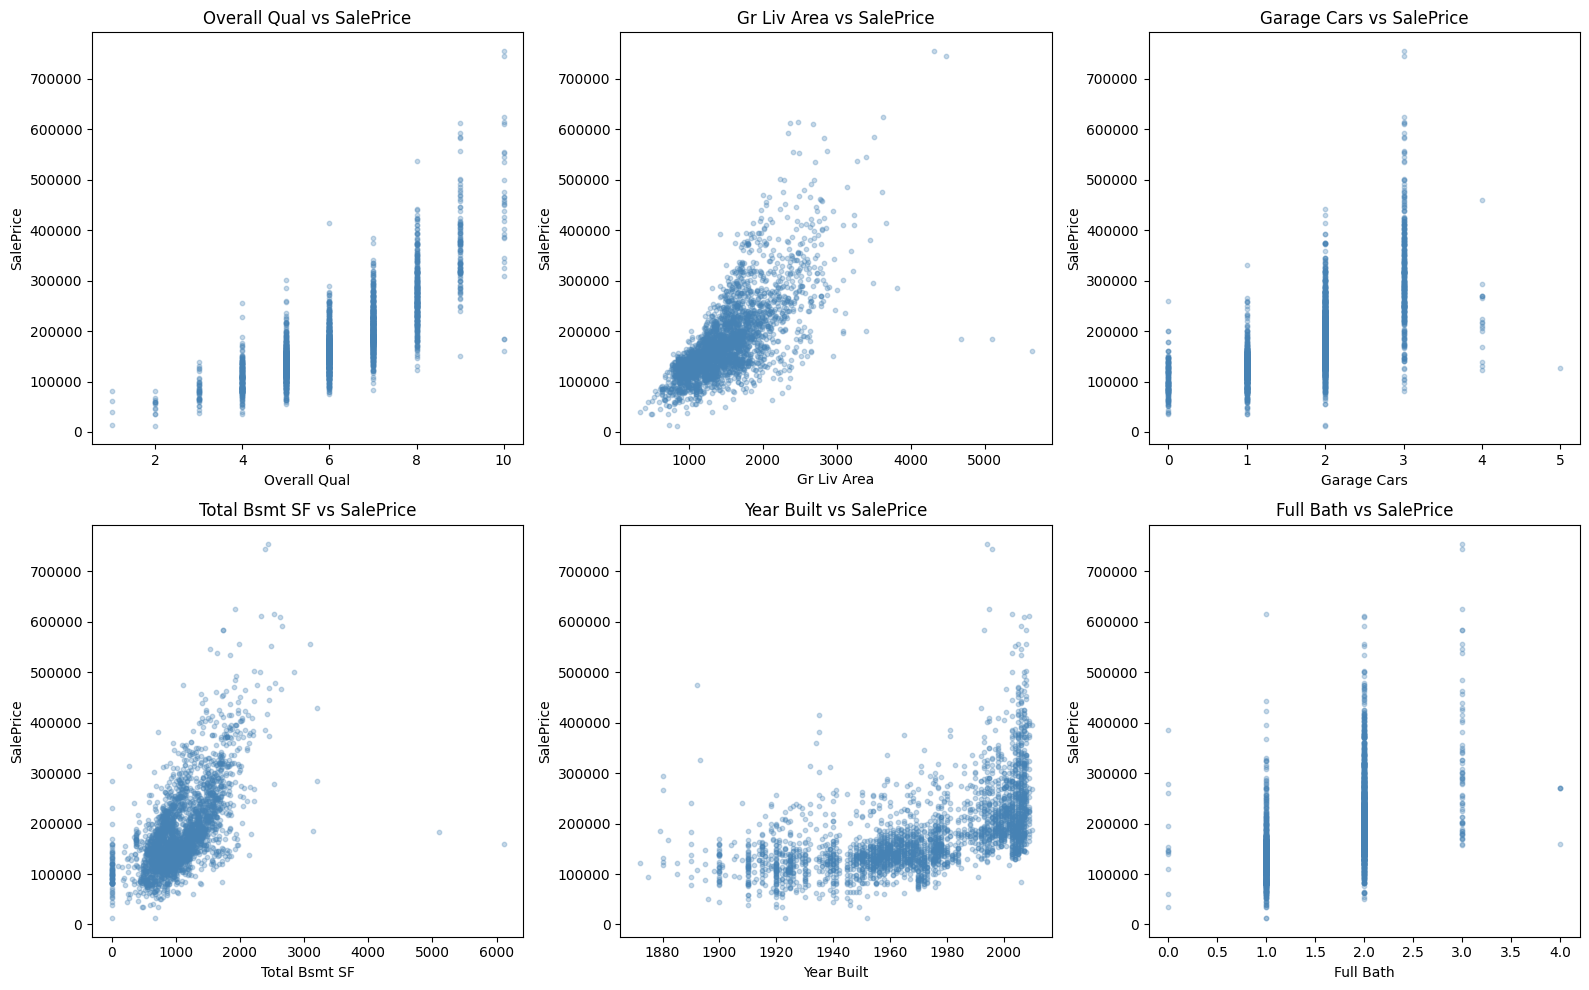

In [7]:
# ── 2.5 Top Features vs SalePrice ───────────
top_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars',
                'Total Bsmt SF', 'Year Built', 'Full Bath']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    if df[feat].dtype == 'object':
        sns.boxplot(x=df[feat], y=df['SalePrice'], ax=axes[i])
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].scatter(df[feat], df['SalePrice'], alpha=0.3, color='steelblue', s=10)
        axes[i].set_xlabel(feat)
        axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

plt.tight_layout()
plt.show()

In [8]:
drop_cols = ['Order', 'PID']  # ID columns
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

X = df.drop(columns=['SalePrice'])
y = np.log1p(df['SalePrice'])  # Log transform target

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()


print(f"Numerical features : {len(num_features)}")
print(f"Categorical features: {len(cat_features)}")

Numerical features : 36
Categorical features: 43


In [9]:
X[num_features] = X[num_features].fillna(X[num_features].median())

for col in cat_features:
    X[col] = X[col].fillna(X[col].mode()[0])

In [10]:
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)
print("Shape after encoding:", X_encoded.shape)


Shape after encoding: (2930, 260)


In [11]:
# ── 3.6 Train-Test Split ────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (2344, 260) | Test: (586, 260)


In [12]:
# ── 3.7 Scale Features ──────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

def build_model(input_dim, layers_config, dropout_rate=0.3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units in layers_config:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1))  # Regression output
    return model

input_dim = X_train_sc.shape[1]
model = build_model(input_dim, layers_config=[256, 128, 64])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,825 (429.00 KB)

 Trainable params: 108,929 (425.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [14]:
# ── Compile ──────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# ── Callbacks ───────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, verbose=1)
]

# ── Train ────────────────────────────────────
history = model.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - loss: 139.9514 - mae: 11.7466 - val_loss: 134.7488 - val_mae: 11.5972 - learning_rate: 0.0010
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 122.4312 - mae: 10.9766 - val_loss: 115.5277 - val_mae: 10.7352 - learning_rate: 0.0010
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 97.9554 - mae: 9.7572 - val_loss: 84.5282 - val_mae: 9.1682 - learning_rate: 0.0010
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65.9321 - mae: 7.8826 - val_loss: 48.4536 - val_mae: 6.9039 - learning_rate: 0.0010
Epoch 5/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 35.3447 - mae: 5.5327 - val_loss: 20.8744 - val_mae: 4.4791 - learning_rate: 0.0010
Epoch 6/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16.6180 - mae: 3.4665 - val_loss: 7.3363 - val_mae: 2.5591 - learning_rate: 0.0010
Epoch 7/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5392 - mae: 2.3491 - val_loss: 2.5974 - val_mae: 1.4102 - learning_rate:

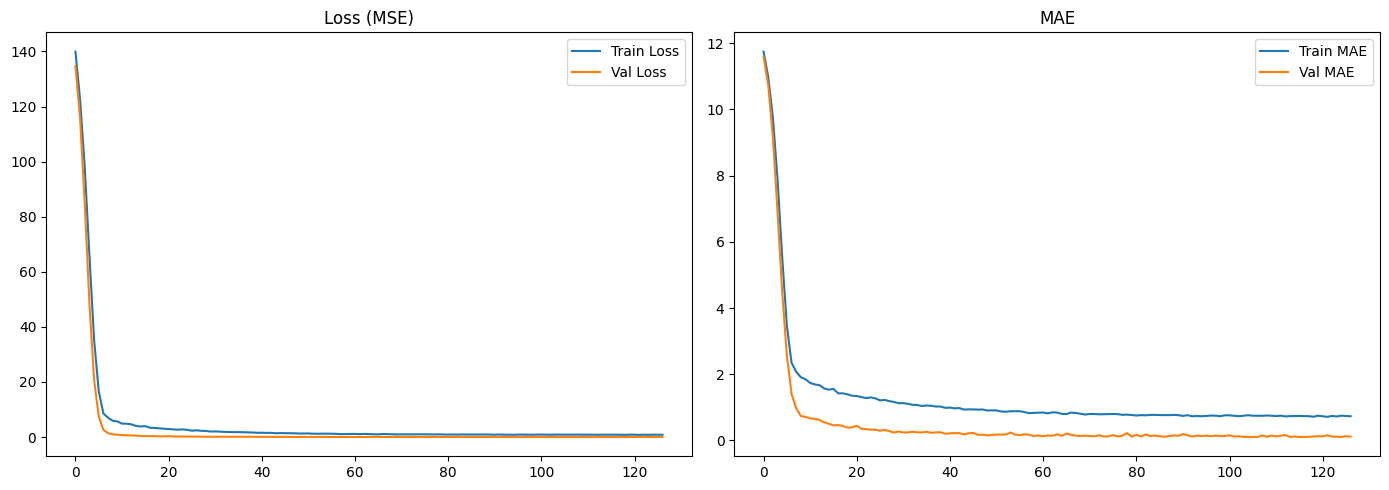

In [15]:
# ── 5.1 Training Curves ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE)')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# ── 5.2 Metrics ──────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_log = model.predict(X_test_sc).flatten()

# Convert back from log scale
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print(f"RMSE : ${rmse:,.0f}")
print(f"MAE  : ${mae:,.0f}")
print(f"R²   : {r2:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step
RMSE : $34,705
MAE  : $18,508
R²   : 0.8498


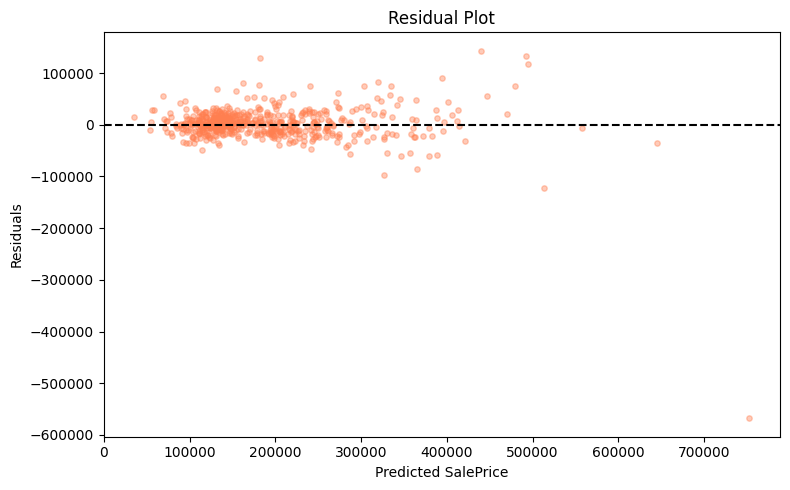

In [17]:
# ── 5.4 Residual Plot ────────────────────────
residuals = y_true - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='coral', s=15)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()